**AI imaging assignment: nuclei microscopy, from raw pixels to an auditable report**

In [1]:
# check the GPU first, no point downloading 10 GB onto a CPU runtime
!nvidia-smi -L
!pip -q install ollama

GPU 0: Tesla T4 (UUID: GPU-09741229-2d50-cf91-85fc-23771a09b2a8)


In [2]:
# install the ollama runtime, models come after
!apt-get -qq update && apt-get -qq install -y zstd > /dev/null
!curl -fsSL https://ollama.com/install.sh | sh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [3]:
import os, subprocess, time, requests

os.environ["OLLAMA_HOST"] = "127.0.0.1:11434"

def ollama_alive():
    # ping the api port, that's all we need
    try:
        requests.get("http://127.0.0.1:11434/api/tags", timeout=2)
        return True
    except Exception:
        return False

if not ollama_alive():
    lf = open("ollama.log", "w")
    subprocess.Popen(["ollama", "serve"], stdout=lf, stderr=lf)
    for _ in range(60):
        if ollama_alive():
            break
        time.sleep(1)

print("server up:", ollama_alive())

server up: True


In [4]:
!ollama pull llama3.2-vision
!ollama pull llama3.2
!ollama list



NAME                      ID              SIZE      MODIFIED               
llama3.2:latest           a80c4f17acd5    2.0 GB    Less than a second ago    
llama3.2-vision:latest    6f2f9757ae97    7.8 GB    21 seconds ago            


In [5]:
!curl -sL -o nuclei_dataset.zip https://github.com/Nickolay-K/Assingnment-3-dataset/raw/main/nuclei_dataset.zip
!unzip -oq nuclei_dataset.zip
!ls nuclei_dataset

dataset_summary.json  metadata.csv  test	    train
make_dataset.py       README.md     test_corrupted  val


In [6]:
import json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage import measure, morphology
from skimage.filters import threshold_otsu
from skimage.measure import regionprops_table

from ollama import chat

seed = 23
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

root = Path("nuclei_dataset")
dev = "cuda" if torch.cuda.is_available() else "cpu"
size = 256

# colour scheme for the whole notebook: magma plus a couple of warm accents
warm = [plt.cm.magma(x) for x in (0.3, 0.55, 0.8)]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#d1495b", "#e07a2f", "#8f2d56"])

# metadata first
meta = pd.read_csv(root / "metadata.csv")
print(meta.groupby("split").density.value_counts())
meta.describe().round(3)

split  density  
test   normal        6
       clustered     2
       dense         2
       sparse        2
train  normal       40
       sparse       14
       clustered    13
       dense        13
val    normal       10
       sparse        4
       clustered     3
       dense         3
Name: count, dtype: int64


,n_objects,mean_intensity,area_fraction,seed
count,112.000,112.000,112.000,1.120000e+02
mean,32.446,0.738,0.081,2.026467e+07
std,20.124,0.033,0.049,6.745766e+03
min,5.000,0.634,0.010,2.026072e+07
25%,18.750,0.725,0.047,2.026074e+07
50%,29.000,0.738,0.077,2.026077e+07
75%,42.750,0.761,0.101,2.027072e+07
max,85.000,0.844,0.216,2.028073e+07


In [7]:
# file lists per split, sorted so everything lines up
def imgs_and_masks(split):
    ims = sorted((root / split / "images").glob("*.png"))
    return ims, [root / split / "masks" / p.name for p in ims]

tr_i, tr_m = imgs_and_masks("train")
va_i, va_m = imgs_and_masks("val")
te_i, te_m = imgs_and_masks("test")
print(len(tr_i), "train /", len(va_i), "val /", len(te_i), "test, running on", dev)

def get_img(p):
    # grayscale, common size, floats in [0,1]
    return np.asarray(Image.open(p).convert("L").resize((size, size), Image.BILINEAR), dtype=np.float32) / 255.0

def get_msk(p):
    return (np.asarray(Image.open(p).resize((size, size), Image.NEAREST), dtype=np.float32) > 127).astype(np.float32)

80 train / 20 val / 12 test, running on cuda


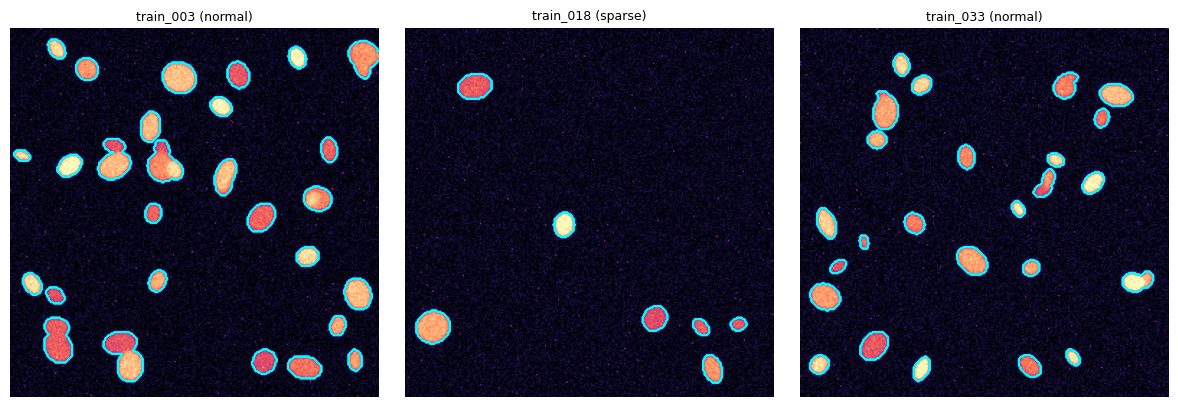

In [8]:
# a few images with their masks drawn on top as contours
picks = [3, 18, 33]
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, k in zip(ax, picks):
    img = get_img(tr_i[k])
    a.imshow(img, cmap="magma")
    a.contour(get_msk(tr_m[k]), colors="cyan", linewidths=0.7)
    a.set_title(f"{tr_i[k].stem} ({meta.set_index('image_id').loc[tr_i[k].stem, 'density']})", fontsize=9)
    a.axis("off")
plt.tight_layout()
plt.show()

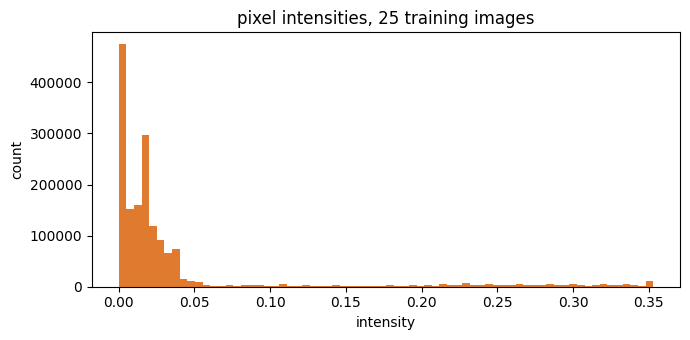

background fraction (pixels under 0.2): 93.17%


In [9]:
# pooled intensity histogram, this drives every thresholding decision later
px = np.concatenate([get_img(p).ravel() for p in tr_i[:25]])
plt.figure(figsize=(7, 3.5))
plt.hist(px, bins=70, color="#e07a2f")
plt.title("pixel intensities, 25 training images")
plt.xlabel("intensity")
plt.ylabel("count")
plt.tight_layout()
plt.show()
print(f"background fraction (pixels under 0.2): {(px < 0.2).mean():.2%}")

In [10]:
# heads up from the module team: some ollama builds throw "unknown model
# architecture: mllama" on llama3.2-vision. quick test call here, and if it
# breaks I switch to qwen2.5vl:7b instead, as the announcement suggests.
import subprocess

vis_model = "llama3.2-vision"
try:
    chat(model=vis_model, messages=[{"role": "user", "content": "say ready"}])
except Exception as e:
    print("llama3.2-vision not usable:", e)
    subprocess.run(["ollama", "pull", "qwen2.5vl:7b"], check=True)
    vis_model = "qwen2.5vl:7b"
print("using:", vis_model)

llama3.2-vision not usable: llama-server process has terminated: exit status 1: error loading model: unknown model architecture: 'mllama'
error loading model: unknown model architecture: 'mllama' (status code: 500)
using: qwen2.5vl:7b


In [11]:
rep = tr_i[12]
rep_img = get_img(rep)
Image.fromarray((rep_img * 255).astype(np.uint8)).save("rep.png")

def see(prompt, temp):
    # one image + one prompt into the vision model
    r = chat(model=vis_model,
             messages=[{"role": "user", "content": prompt, "images": ["rep.png"]}],
             options={"temperature": temp})
    return r["message"]["content"]

print(see("What is in this picture?", 0.7))

The image appears to be a microscopic view of some biological entities, likely cells, under a dark field or phase-contrast microscope. The bright spots represent the cells or particles being illuminated by the microscope's light source, which passes through the specimen and is then refracted and focused onto the detector. The dark background is typical of dark field microscopy, where only the light that is scattered by the specimen is detected, providing a high contrast image of the specimen against a dark background.


In [12]:
# my tuned prompt: describe, don't diagnose, and give me JSON I can parse
vision_prompt = """Look at this microscopy image and describe it factually.
Do not diagnose anything and do not guess at clinical meaning. Stick to what is visible.
Answer with one JSON object only, using these keys:
"modality" (what kind of imaging this looks like),
"tissue_type" (or "uncertain" if you cannot tell),
"notable_features" (a short list of things you can actually see),
"image_quality" ("good", "acceptable" or "poor").
If unsure about a key, put "uncertain". No text outside the JSON."""

def grab_json(txt):
    # models love wrapping json in fences, so strip those and cut to the braces
    t = txt.strip()
    if t.startswith("```"):
        t = t.split("\n", 1)[1].rsplit("```", 1)[0]
    a, b = t.find("{"), t.rfind("}")
    if a == -1:
        return None
    try:
        return json.loads(t[a:b + 1])
    except json.JSONDecodeError:
        return None

tuned = see(vision_prompt, 0)
print(tuned)
print("\nparsed:", grab_json(tuned))

```json
{
  "modality": "microscopy",
  "tissue_type": "uncertain",
  "notable_features": [
    "elliptical shapes",
    "various sizes",
    "dark background",
    "light gray to white intensity"
  ],
  "image_quality": "acceptable"
}
```

parsed: {'modality': 'microscopy', 'tissue_type': 'uncertain', 'notable_features': ['elliptical shapes', 'various sizes', 'dark background', 'light gray to white intensity'], 'image_quality': 'acceptable'}


In [13]:
# same prompt, three temperatures, two runs each
for temp in (0.2, 0.7, 1.0):
    r1, r2 = see(vision_prompt, temp), see(vision_prompt, temp)
    print(f"temperature {temp}: runs identical -> {r1 == r2}")
    print("  run 1 starts:", r1[:100].replace("\n", " "))
    print("  run 2 starts:", r2[:100].replace("\n", " "))
    print()

temperature 0.2: runs identical -> False
  run 1 starts: ```json {   "modality": "microscopy",   "tissue_type": "uncertain",   "notable_features": [     "ell
  run 2 starts: ```json {   "modality": "microscopy",   "tissue_type": "uncertain",   "notable_features": ["dots", "

temperature 0.7: runs identical -> False
  run 1 starts: ```json {   "modality": "microscopy",   "tissue_type": "uncertain",   "notable_features": [     "sma
  run 2 starts: ```json {   "modality": "microscopy",   "tissue_type": "uncertain",   "notable_features": ["clusters

temperature 1.0: runs identical -> False
  run 1 starts: ```json {   "modality": "microscopy",   "tissue_type": "uncertain",   "notable_features": [     "dif
  run 2 starts: ```json {   "modality": "fluorescence microscopy",   "tissue_type": "uncertain",   "notable_features



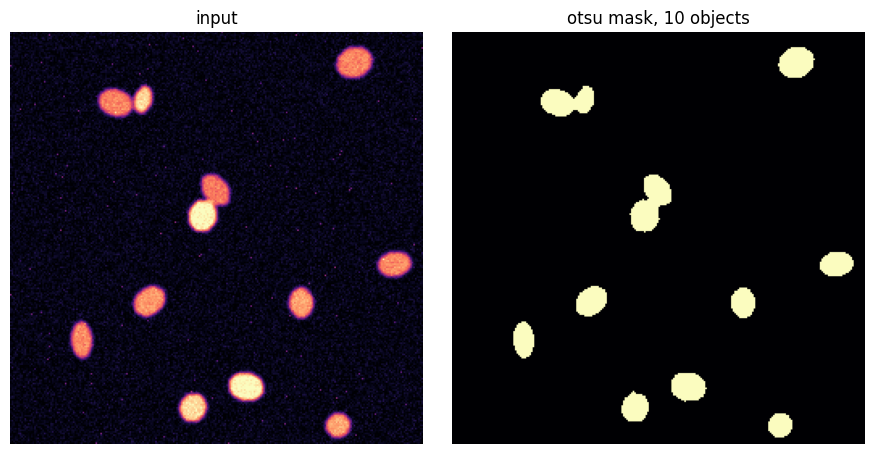

,label,area,perimeter,eccentricity,solidity,mean_intensity
count,10.00,10.00,10.00,10.00,10.00,10.00
mean,5.50,305.00,66.91,0.63,0.94,0.26
std,3.03,110.67,19.55,0.20,0.05,0.02
min,1.00,183.00,47.21,0.26,0.84,0.24
25%,3.25,234.75,57.02,0.55,0.95,0.25
50%,5.50,267.50,59.16,0.62,0.96,0.25
75%,7.75,328.75,65.67,0.79,0.97,0.27
max,10.00,544.00,108.33,0.89,0.97,0.32


In [14]:
def otsu_mask(g):
    # global threshold, then close small gaps and drop specks
    m = g > threshold_otsu(g)
    m = morphology.closing(m, morphology.disk(1))
    return morphology.remove_small_objects(m, min_size=30)

props = ("label", "area", "perimeter", "eccentricity", "solidity", "mean_intensity")

def props_df(g, m):
    lab = measure.label(m)
    if lab.max() == 0:
        return pd.DataFrame(columns=props)
    return pd.DataFrame(regionprops_table(lab, intensity_image=g, properties=props))

rep_mask = otsu_mask(rep_img)
rep_df = props_df(rep_img, rep_mask)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(rep_img, cmap="magma")
ax[0].set_title("input")
ax[1].imshow(rep_mask, cmap="magma")
ax[1].set_title(f"otsu mask, {len(rep_df)} objects")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()
rep_df.describe().round(2)

In [15]:
def make_summary(df, name):
    # this text is the ONLY thing the language model gets to see
    if not len(df):
        return f"{name}: zero objects found by segmentation."
    return (f"{name}: {len(df)} objects. area min {df.area.min():.0f}, max {df.area.max():.0f}, "
            f"mean {df.area.mean():.0f} px. eccentricity mean {df.eccentricity.mean():.2f}. "
            f"solidity mean {df.solidity.mean():.2f}. object intensity mean {df.mean_intensity.mean():.2f}.")

text_prompt = """Below is a set of measurements from an automated analysis of one microscopy
image. You have not seen the image. Work only from the numbers.
Give me:
DESCRIPTION: a plain paragraph, three sentences or fewer, describing the scene.
RECORD: one JSON object with keys "n_objects" (int), "density_class" (one of
"sparse", "moderate", "dense"), "shape_regularity" ("regular" or "irregular"),
"quality_flag" ("ok" or "review").
Use exactly those two labels, DESCRIPTION: then RECORD:. Never add numbers I did not give you.

Measurements: """

def call_text_llm(prompt_text):
    r = chat(model="llama3.2", messages=[{"role": "user", "content": prompt_text}],
             options={"temperature": 0})
    return r["message"]["content"]

rep_summary = make_summary(rep_df, rep.stem)
print("sent to the model:", rep_summary, "\n")
reply = call_text_llm(text_prompt + rep_summary)
print(reply)

# pull the two parts back out; if the model dropped the RECORD label,
# just hunt for the braces in the whole reply instead
desc_part = reply.split("RECORD:")[0].replace("DESCRIPTION:", "").strip()
rec_t2 = grab_json(reply.split("RECORD:")[-1] if "RECORD:" in reply else reply)
print("\nparsed record:", rec_t2)

sent to the model: train_012: 10 objects. area min 183, max 544, mean 305 px. eccentricity mean 0.63. solidity mean 0.94. object intensity mean 0.26. 

The scene appears to be a collection of objects with varying sizes and shapes, possibly biological in nature. The objects are relatively uniform in terms of their solidity and intensity, suggesting a consistent composition. The range of areas and eccentricities indicates a degree of diversity among the objects.

RECORD:
{
  "n_objects": 10,
  "density_class": "moderate",
  "shape_regularity": "irregular",
  "quality_flag": "ok"
}

parsed record: {'n_objects': 10, 'density_class': 'moderate', 'shape_regularity': 'irregular', 'quality_flag': 'ok'}


In [16]:
# sanity check against ground truth, since this dataset actually has it
gt_n = int(meta.set_index("image_id").loc[rep.stem, "n_objects"])
print("otsu found:      ", len(rep_df))
print("llm reported:    ", None if rec_t2 is None else rec_t2.get("n_objects"))
print("metadata truth:  ", gt_n)

otsu found:       10
llm reported:     10
metadata truth:   12


In [17]:
class PairSet(Dataset):
    # image + mask pairs, augmentation only for training
    def __init__(self, ims, msks, aug=False):
        self.ims, self.msks, self.aug = list(ims), list(msks), aug

    def __len__(self):
        return len(self.ims)

    def __getitem__(self, i):
        img, msk = get_img(self.ims[i]), get_msk(self.msks[i])
        if self.aug:
            if random.random() < 0.5:
                img, msk = np.fliplr(img).copy(), np.fliplr(msk).copy()
            if random.random() < 0.5:
                img, msk = np.flipud(img).copy(), np.flipud(msk).copy()
            k = random.randint(0, 3)
            if k:
                img, msk = np.rot90(img, k).copy(), np.rot90(msk, k).copy()
        return torch.from_numpy(img)[None], torch.from_numpy(msk)[None]

bs = 4
tr_loader = DataLoader(PairSet(tr_i, tr_m, aug=True), batch_size=bs, shuffle=True,
                       generator=torch.Generator().manual_seed(seed))
va_loader = DataLoader(PairSet(va_i, va_m), batch_size=bs)
print(len(tr_loader), "train batches of", bs)

20 train batches of 4


In [18]:
class ConvBlock(nn.Module):
    # conv-bn-relu twice, the standard unet building block
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self, w=32):
        super().__init__()
        self.d1, self.d2, self.d3 = ConvBlock(1, w), ConvBlock(w, w * 2), ConvBlock(w * 2, w * 4)
        self.mid = ConvBlock(w * 4, w * 8)
        self.pool = nn.MaxPool2d(2)
        self.t3, self.t2, self.t1 = (nn.ConvTranspose2d(w * 8, w * 4, 2, 2),
                                     nn.ConvTranspose2d(w * 4, w * 2, 2, 2),
                                     nn.ConvTranspose2d(w * 2, w, 2, 2))
        self.u3, self.u2, self.u1 = ConvBlock(w * 8, w * 4), ConvBlock(w * 4, w * 2), ConvBlock(w * 2, w)
        self.last = nn.Conv2d(w, 1, 1)

    def forward(self, x):
        a = self.d1(x)
        b = self.d2(self.pool(a))
        c = self.d3(self.pool(b))
        m = self.mid(self.pool(c))
        x = self.u3(torch.cat([self.t3(m), c], 1))
        x = self.u2(torch.cat([self.t2(x), b], 1))
        x = self.u1(torch.cat([self.t1(x), a], 1))
        return self.last(x)

net = SmallUNet(w=32).to(dev)
print(f"{sum(p.numel() for p in net.parameters()) / 1e6:.2f}M parameters")

1.93M parameters


In [19]:
def soft_dice_loss(logits, y, eps=1e-7):
    p = torch.sigmoid(logits)
    inter = (p * y).sum(dim=(1, 2, 3))
    tot = p.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3))
    return (1 - (2 * inter + eps) / (tot + eps)).mean()

def hard_dice(logits, y, eps=1e-7):
    p = (torch.sigmoid(logits) > 0.5).float()
    inter = (p * y).sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (p.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3)) + eps)).mean().item()

def iou(logits, y, eps=1e-7):
    p = (torch.sigmoid(logits) > 0.5).float()
    inter = (p * y).sum(dim=(1, 2, 3))
    uni = p.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (uni + eps)).mean().item()

In [20]:
epochs, lr = 12, 5e-4
opt = torch.optim.Adam(net.parameters(), lr=lr)
hist = {"tr": [], "va": [], "dice": []}

for ep in range(1, epochs + 1):
    net.train()
    running, n = 0.0, 0
    for x, y in tr_loader:
        x, y = x.to(dev), y.to(dev)
        loss = soft_dice_loss(net(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        running += loss.item() * len(x)
        n += len(x)
    net.eval()
    vloss, vdice, vn = 0.0, 0.0, 0
    with torch.no_grad():
        for x, y in va_loader:
            x, y = x.to(dev), y.to(dev)
            out = net(x)
            vloss += soft_dice_loss(out, y).item() * len(x)
            vdice += hard_dice(out, y) * len(x)
            vn += len(x)
    hist["tr"].append(running / n)
    hist["va"].append(vloss / vn)
    hist["dice"].append(vdice / vn)
    print(f"ep {ep:2d}  train {running / n:.4f}  val {vloss / vn:.4f}  dice {vdice / vn:.4f}")

ep  1  train 0.7362  val 0.8648  dice 0.4247
ep  2  train 0.6765  val 0.7660  dice 0.9435
ep  3  train 0.6370  val 0.6592  dice 0.8595
ep  4  train 0.6015  val 0.6126  dice 0.9153
ep  5  train 0.5633  val 0.5636  dice 0.9679
ep  6  train 0.5245  val 0.5280  dice 0.9728
ep  7  train 0.4814  val 0.4757  dice 0.9851
ep  8  train 0.4361  val 0.4210  dice 0.9877
ep  9  train 0.3911  val 0.4026  dice 0.9918
ep 10  train 0.3437  val 0.3486  dice 0.9905
ep 11  train 0.3018  val 0.3059  dice 0.9958
ep 12  train 0.2606  val 0.2514  dice 0.9938


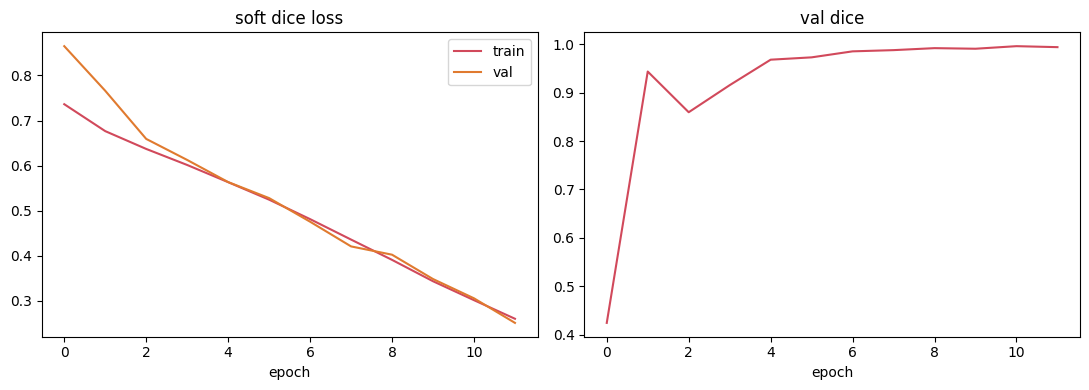

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["tr"], label="train")
ax[0].plot(hist["va"], label="val")
ax[0].set_title("soft dice loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(hist["dice"], color="#d1495b")
ax[1].set_title("val dice")
ax[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

val mean dice 0.9938, mean iou 0.9877


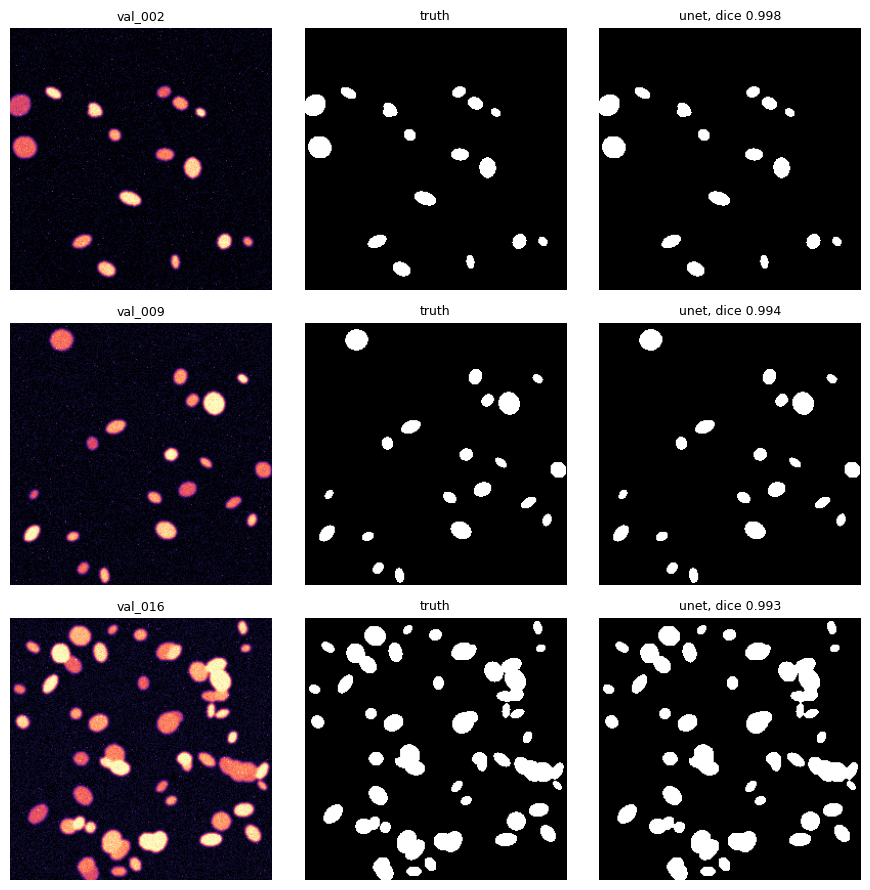

In [22]:
def unet_predict(g):
    net.eval()
    with torch.no_grad():
        t = torch.from_numpy(g)[None, None].to(dev)
        return (torch.sigmoid(net(t))[0, 0].cpu().numpy() > 0.5)

def mask_dice(a, b, eps=1e-7):
    a, b = a.astype(bool), b.astype(bool)
    return float((2 * np.logical_and(a, b).sum() + eps) / (a.sum() + b.sum() + eps))

# final numbers on the whole val split
ds, us = [], []
net.eval()
with torch.no_grad():
    for x, y in va_loader:
        out = net(x.to(dev))
        yy = y.to(dev)
        for i in range(len(x)):
            ds.append(hard_dice(out[i:i + 1], yy[i:i + 1]))
            us.append(iou(out[i:i + 1], yy[i:i + 1]))
print(f"val mean dice {np.mean(ds):.4f}, mean iou {np.mean(us):.4f}")

# input / truth / prediction for three validation images
fig, ax = plt.subplots(3, 3, figsize=(9, 9))
for r, k in enumerate([2, 9, 16]):
    g, gt = get_img(va_i[k]), get_msk(va_m[k])
    pr = unet_predict(g)
    ax[r, 0].imshow(g, cmap="magma")
    ax[r, 0].set_title(va_i[k].stem, fontsize=9)
    ax[r, 1].imshow(gt, cmap="gray")
    ax[r, 1].set_title("truth", fontsize=9)
    ax[r, 2].imshow(pr, cmap="gray")
    ax[r, 2].set_title(f"unet, dice {mask_dice(pr, gt):.3f}", fontsize=9)
    for a in ax[r]:
        a.axis("off")
plt.tight_layout()
plt.show()

In [23]:
# so, did the unet actually beat plain otsu? per-image scores on val
tab = pd.DataFrame([{
    "image": p.stem,
    "otsu": mask_dice(otsu_mask(get_img(p)), get_msk(m)),
    "unet": mask_dice(unet_predict(get_img(p)), get_msk(m)),
} for p, m in zip(va_i, va_m)])
tab["diff"] = (tab.unet - tab.otsu).round(4)
print(tab.round(4).to_string(index=False))
print(f"\nmeans: otsu {tab.otsu.mean():.4f} vs unet {tab.unet.mean():.4f}")
print("unet wins on", (tab["diff"] > 0).sum(), "of", len(tab), "images")

  image   otsu   unet   diff
val_000 0.9754 0.9922 0.0168
val_001 0.9764 0.9902 0.0138
val_002 0.9769 0.9982 0.0213
val_003 0.9772 0.9929 0.0157
val_004 0.9755 0.9951 0.0196
val_005 0.9764 0.9951 0.0186
val_006 0.9731 0.9920 0.0190
val_007 0.9796 0.9948 0.0152
val_008 0.9829 0.9962 0.0133
val_009 0.9738 0.9935 0.0197
val_010 0.9763 0.9960 0.0197
val_011 0.9842 0.9958 0.0116
val_012 0.9786 0.9894 0.0109
val_013 0.9763 0.9941 0.0178
val_014 0.9773 0.9945 0.0171
val_015 0.9777 0.9916 0.0139
val_016 0.9794 0.9929 0.0135
val_017 0.9817 0.9939 0.0122
val_018 0.9739 0.9898 0.0158
val_019 0.9772 0.9979 0.0207

means: otsu 0.9775 vs unet 0.9938
unet wins on 20 of 20 images


In [24]:
pipe_prompt = """You write structured records for an automated microscopy report.
Input: measurements from one image, given below. That is all you know.
Output, in this exact shape:
RECORD:
{"image_id": "...", "n_objects": <int>, "mean_area": <number>, "density_class":
"sparse"|"moderate"|"dense", "quality_flag": "ok"|"review"}
REPORT:
A short paragraph, two to four sentences, plain language, no diagnosis, no numbers
that are not in the measurements. Flag quality_flag as "review" if anything looks odd.

Measurements: """

def run_pipeline(img_path):
    g = get_img(img_path)
    m = morphology.remove_small_objects(unet_predict(g), min_size=30)
    df = props_df(g, m)
    summary = make_summary(df, img_path.stem)
    if not len(df):
        rec, rep_text = {"image_id": img_path.stem, "n_objects": 0, "mean_area": 0,
                         "density_class": "sparse", "quality_flag": "review"}, "Empty mask, skipped the LLM."
    else:
        out = call_text_llm(pipe_prompt + summary)
        body = out.split("RECORD:", 1)[-1]
        rec_txt, rep_text = (body.split("REPORT:", 1) + [""])[:2] if "REPORT:" in body else (body, "")
        rec = grab_json(rec_txt) or {"error": "bad json"}
        rep_text = rep_text.strip()
    rec["n_objects_measured"] = len(df)
    rec["mean_area_measured"] = round(float(df.area.mean()), 1) if len(df) else 0.0
    rec["narrative"] = rep_text
    return rec

records = [run_pipeline(p) for p in te_i]
out_df = pd.DataFrame(records)
out_df.to_csv("test_set_records.csv", index=False)
print("wrote test_set_records.csv")
out_df.drop(columns=["narrative"])

wrote test_set_records.csv


,image_id,n_objects,mean_area,density_class,quality_flag,n_objects_measured,mean_area_measured
0,test_000,8,194,dense,ok,8,193.6
1,test_001,14,204,dense,ok,14,204.1
2,test_002,26,222,dense,ok,26,221.5
3,test_003,19,207,dense,ok,19,206.7
4,test_004,43,331,dense,ok,43,331.3
5,test_005,15,437,dense,ok,15,437.1
6,test_006,8,201,dense,ok,8,200.9
7,test_007,23,208,dense,ok,23,207.8
8,test_008,23,241,dense,ok,23,241.5
9,test_009,21,181,dense,ok,21,181.2


In [25]:
# one full example, then the audit: does the llm count match my count?
print(json.dumps({k: v for k, v in records[3].items() if k != "narrative"}, indent=2))
print("\nnarrative:", records[3]["narrative"])

bad = out_df[pd.to_numeric(out_df.get("n_objects"), errors="coerce") != out_df.n_objects_measured]
print(f"\nmismatched counts: {len(bad)} of {len(out_df)} records")

{
  "image_id": "test_003",
  "n_objects": 19,
  "mean_area": 207,
  "density_class": "dense",
  "quality_flag": "ok",
  "n_objects_measured": 19,
  "mean_area_measured": 206.7
}

narrative: The image contains a dense cluster of objects. The objects appear to be well-defined and evenly sized, with a moderate level of intensity. Overall, the image quality is good.

mismatched counts: 0 of 12 records


bce: val dice 0.9005
dice: val dice 0.8396
bce+dice: val dice 0.8874


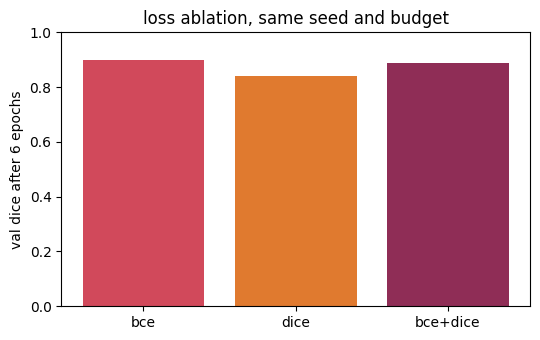

In [26]:
def bce_loss(logits, y):
    return F.binary_cross_entropy_with_logits(logits, y)

def bce_dice(logits, y):
    return bce_loss(logits, y) + soft_dice_loss(logits, y)

def quick_train(loss_fn, tag, n_ep=6):
    # smaller width to keep the ablation cheap, same seed for a fair fight
    torch.manual_seed(seed)
    m = SmallUNet(w=16).to(dev)
    o = torch.optim.Adam(m.parameters(), lr=1e-3)
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(PairSet(tr_i, tr_m, aug=True), batch_size=8, shuffle=True, generator=g)
    for _ in range(n_ep):
        m.train()
        for x, y in dl:
            x, y = x.to(dev), y.to(dev)
            l = loss_fn(m(x), y)
            o.zero_grad()
            l.backward()
            o.step()
    m.eval()
    d, n = 0.0, 0
    with torch.no_grad():
        for x, y in va_loader:
            d += hard_dice(m(x.to(dev)), y.to(dev)) * len(x)
            n += len(x)
    print(f"{tag}: val dice {d / n:.4f}")
    return d / n

ablation = {tag: quick_train(fn, tag) for tag, fn in
            [("bce", bce_loss), ("dice", soft_dice_loss), ("bce+dice", bce_dice)]}

plt.figure(figsize=(5.5, 3.5))
plt.bar(list(ablation), list(ablation.values()), color=["#d1495b", "#e07a2f", "#8f2d56"])
plt.ylabel("val dice after 6 epochs")
plt.title("loss ablation, same seed and budget")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()